In [98]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from minisom import MiniSom

from pathlib import Path
import zipfile, re, shutil
from glob import glob

# Approach and Motivation:

# Code:

In [4]:
ds = xr.open_dataset("/home/scratch/jtoniolo/483/ERA5_vars.nc")
print(ds)
print(list(ds.data_vars))

<xarray.Dataset>
Dimensions:         (valid_time: 999, latitude: 133, longitude: 241,
                     pressure_level: 2)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 2020-01-02T09:00:00 ... 2025-...
  * latitude        (latitude) float64 53.0 52.75 52.5 52.25 ... 20.5 20.25 20.0
  * longitude       (longitude) float64 -125.0 -124.8 -124.5 ... -65.25 -65.0
  * pressure_level  (pressure_level) float64 850.0 500.0
Data variables:
    tcwv            (valid_time, latitude, longitude) float32 ...
    cape            (valid_time, latitude, longitude) float32 ...
    msl             (valid_time, latitude, longitude) float32 ...
    tp              (valid_time, latitude, longitude) float32 ...
    z850            (valid_time, latitude, longitude) float32 ...
    z500            (valid_time, latitude, longitude) float32 ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:       

In [12]:
ds

<xarray.Dataset>
Dimensions:         (valid_time: 999, latitude: 133, longitude: 241,
                     pressure_level: 2)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 2020-01-02T09:00:00 ... 2025-...
  * latitude        (latitude) float64 53.0 52.75 52.5 52.25 ... 20.5 20.25 20.0
  * longitude       (longitude) float64 -125.0 -124.8 -124.5 ... -65.25 -65.0
  * pressure_level  (pressure_level) float64 850.0 500.0
Data variables:
    tcwv            (valid_time, latitude, longitude) float32 ...
    cape            (valid_time, latitude, longitude) float32 ...
    msl             (valid_time, latitude, longitude) float32 ...
    tp              (valid_time, latitude, longitude) float32 ...
    z850            (valid_time, latitude, longitude) float32 ...
    z500            (valid_time, latitude, longitude) float32 ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-27T22:22 GRIB to CDM+CF via cfgrib-0.9.1...

In [14]:
g0 = 9.80665
ds['z500'] = ds['z500'] / g0
ds['z500'].attrs['units'] = 'm' 

In [16]:
ds = ds.rename({'tcwv':'pwat'})
ds['pwat'].attrs['units'] = 'mm' 

In [18]:
z500 = ds['z500'].values
pwat = ds['pwat'].values

N, ny, nx = z500.shape
P = ny * nx

X = np.concatenate([z500.reshape(N, P), pwat.reshape(N, P)], axis=1) 
print(X.shape)

(999, 64106)


### Setting up the SOM... tuning to come soon outside of manually messing with hyperparameters

In [19]:
scaler = StandardScaler()
Xz = scaler.fit_transform(X)

In [20]:
m, n = 4, 4
sigma = 2.0
learning_rate = 0.1
num_iterations = 5000
seed = 420

som = MiniSom(
    x=m,
    y=n,
    input_len=Xz.shape[1],
    sigma=sigma,
    learning_rate=learning_rate,
    neighborhood_function='gaussian',
    random_seed=seed
)

som.random_weights_init(Xz)
som.train_random(Xz, num_iterations, verbose=True)

bmus = np.array([som.winner(x) for x in Xz])
print("BMU shape:", bmus.shape)

node_index = bmus[:,0] * n + bmus[:,1] 

 [ 5000 / 5000 ] 100% - 0:00:00 left 
 quantization error: 164.28199882537896
BMU shape: (999, 2)


In [23]:
m, n, _ = som.get_weights().shape

lats = ds['z500'].latitude.values
lons = ds['z500'].longitude.values
sums_z = np.zeros((m, n, ny, nx), dtype=np.float64)
sums_w = np.zeros((m, n, ny, nx), dtype=np.float64)
counts = np.zeros((m, n), dtype=np.int64)

for i in range(N):
    r, c = bmus[i]
    sums_z[r, c] += z500[i]
    sums_w[r, c] += pwat[i]
    counts[r, c] += 1

mean_z = np.full((m, n, ny, nx), np.nan, dtype=np.float32)
mean_w = np.full((m, n, ny, nx), np.nan, dtype=np.float32)

for r in range(m):
    for c in range(n):
        if counts[r, c] > 0:
            mean_z[r, c] = sums_z[r, c] / counts[r, c]
            mean_w[r, c] = sums_w[r, c] / counts[r, c]

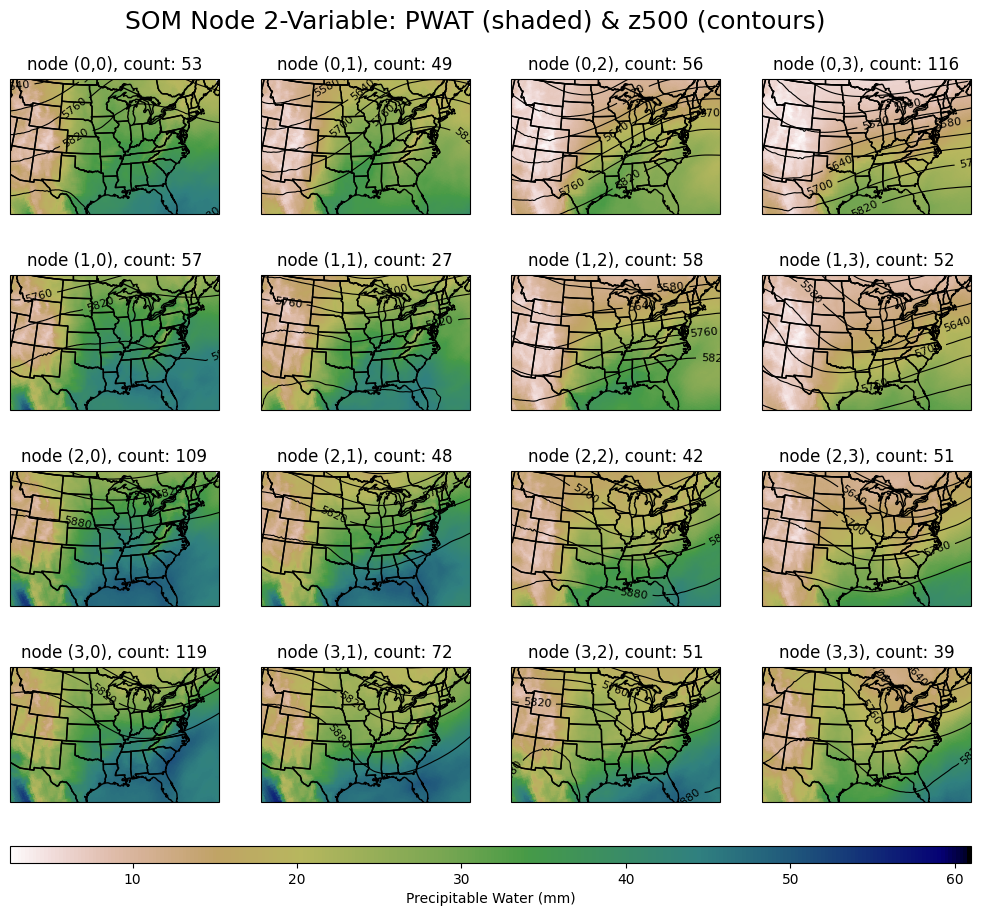

In [25]:
from matplotlib.gridspec import GridSpec

# flattening the nodes similar to GEFS SOM notebook so they can be plotted
z500_avg_data = [mean_z[r, c] for r in range(m) for c in range(n)]
tcwv_avg_data = [mean_w[r, c] for r in range(m) for c in range(n)]
frequencies   = [counts[r, c] for r in range(m) for c in range(n)]
node_keys     = [f"({r},{c})" for r in range(m) for c in range(n)]

length = n
width = m

# combined_training notebook from GEFS_nodes style:
gs = GridSpec(nrows=width + 1, ncols=length, height_ratios=[1]*width + [0.1])
fig = plt.figure(figsize=(3.1 * length, 2.6 * width))

ax = [
    fig.add_subplot(gs[(i // length, i % length)], projection=ccrs.LambertConformal())
    for i in range(len(z500_avg_data))
]

# determining the max and min values for the shared colorbars and contours, respectively
tcwv_vmin = np.nanmin(mean_w)
tcwv_vmax = np.nanmax(mean_w)
zmin = np.nanmin(mean_z)
zmax = np.nanmax(mean_z)
z_levels = np.arange(60 * np.floor(zmin / 60), 60 * np.ceil(zmax / 60) + 60, 60) # kept this like NWP maps where it contours every 60m

for i in range(len(z500_avg_data)):
    ax[i].set_extent([-112, -72, 26, 48], crs=ccrs.PlateCarree())   # not the full CONUS since our ERO days came from ECONUS
    ax[i].add_feature(cfeature.BORDERS)
    ax[i].add_feature(cfeature.STATES)

    cf = ax[i].pcolormesh(
        lons, lats, tcwv_avg_data[i],
        cmap="gist_earth_r",   # will probably design a custom cmap later... using a default one for example purposes
        vmin=tcwv_vmin,
        vmax=tcwv_vmax,
        shading="auto",
        transform=ccrs.PlateCarree()
    )
# contouring 500mb heights like any NWP output
    cn = ax[i].contour(
        lons, lats, z500_avg_data[i],
        levels=z_levels,
        colors="k",
        linewidths=0.8,
        transform=ccrs.PlateCarree()
    )
    ax[i].clabel(cn, fmt="%d", fontsize=8)
    ax[i].set_title(f"node {node_keys[i]}, count: {int(frequencies[i])}")

cax = fig.add_subplot(gs[-1, :])
fig.colorbar(cf, cax=cax, label="Precipitable Water (mm)", orientation="horizontal")

plt.suptitle("SOM Node 2-Variable: PWAT (shaded) & z500 (contours)", fontsize=18, y=0.93)
plt.show()

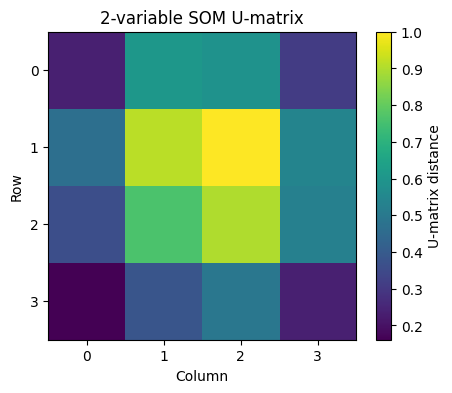

In [26]:
u = som.distance_map()

plt.figure(figsize=(5, 4))
plt.imshow(u, origin="upper", cmap="viridis")
plt.colorbar(label="U-matrix distance")
plt.xticks(range(n))
plt.yticks(range(m))
plt.xlabel("Column")
plt.ylabel("Row")
plt.title("2-variable SOM U-matrix")
plt.show()

### Instead of grabbing the nodes itself and plotting mean values like we did above, we are now pulling the members of the nodes

In [99]:
r_sel, c_sel = 1, 2

member_idx = np.where((bmus[:, 0] == r_sel) & (bmus[:, 1] == c_sel))[0]
member_times = ds["valid_time"].isel(valid_time=member_idx)
print(member_times[:10].values)

['2020-05-03T09:00:00.000000000' '2020-05-04T09:00:00.000000000'
 '2020-05-14T09:00:00.000000000' '2020-05-15T09:00:00.000000000'
 '2020-10-25T09:00:00.000000000' '2020-10-28T09:00:00.000000000'
 '2020-10-29T09:00:00.000000000' '2021-04-28T09:00:00.000000000'
 '2021-04-29T09:00:00.000000000' '2021-05-04T09:00:00.000000000']


### Pulling the dates in the form I labeled my files... ex: 20250503

In [100]:
member_dates = [
    np.datetime_as_string(t, unit="D").replace("-", "")
    for t in member_times.values
]

In [105]:
ero_files = Path("/home/scratch/jtoniolo/483/masks_94e09")
member_mask_files = []

for ymd in member_dates:
    matches = sorted(ero_files.glob(f"{ymd}_*_mask.nc"))
    if len(matches) > 0:
        member_mask_files.append(matches[0])

# quick test to see whta kinds of days so I can confirm
for f in member_mask_files[:10]:
    print(f.name)

20200503_94e0309_mask.nc
20200504_94e0409_mask.nc
20200514_94e1409_mask.nc
20200515_94e1509_mask.nc
20201025_94e2509_mask.nc
20201028_94e2809_mask.nc
20201029_94e2909_mask.nc
20210428_94e2809_mask.nc
20210429_94e2909_mask.nc
20210504_94e0409_mask.nc


In [106]:
ero_members = []

for f in member_mask_files:
    tmp = xr.open_dataset(f)
    ero_members.append(tmp["ero"].values)

ero_members = np.stack(ero_members, axis=0) # had to look this up... because of our multiple risk layers

### New main product we came up with: a frquency of occurance map. Thus we are computing what fraction of the days in this node had a slight or greater ERO. This is essentially a heatmap analysis... more products lkke this to come later

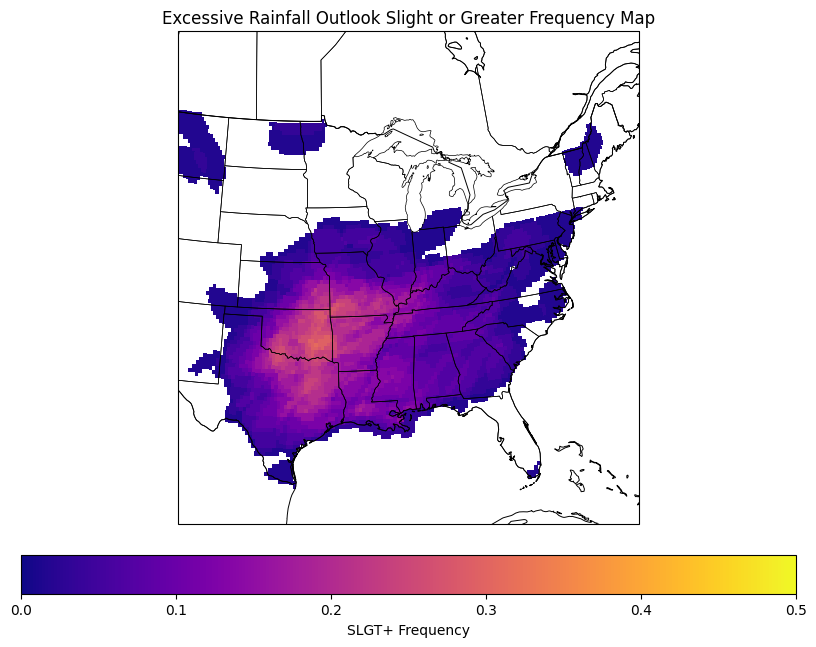

In [110]:
slight_plus = (ero_members >= 2).astype(float) # since a dn of 2 is a SLGT
mean_slight_plus = slight_plus.mean(axis=0)
plot_slight_plus = np.where(mean_slight_plus == 0, np.nan, mean_slight_plus)

fig = plt.figure(figsize=(10, 8))
ax = plt.subplot(1, 1, 1, projection=ccrs.LambertConformal())

ax.set_extent([-105, -74, 23, 53], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.add_feature(cfeature.BORDERS, linewidth=0.7)
ax.add_feature(cfeature.STATES, linewidth=0.5)

cf = ax.pcolormesh(
    lons,
    lats,
    plot_slight_plus,
    cmap="plasma",
    vmin=0,
    vmax=0.5,
    shading="auto",
    transform=ccrs.PlateCarree()
)

plt.colorbar(cf, ax=ax, orientation="horizontal", pad=0.05, label="SLGT+ Frequency")
ax.set_title("Excessive Rainfall Outlook Slight or Greater Frequency Map")
plt.show()

# Assessment: